# 1. Data cleaning

- Tập dữ liệu: Sử dụng dữ liệu từ file lab_02.csv (https://drive.google.com/file/d/1ged7DshE3HOemSfxcKmc4r23TjJknQR4/view?usp=drive_link)
- Tiến hành các bước xử lý dữ liệu
  + Xử lý missing dữ liệu
  + Chuẩn hóa dữ liệu
  + Đồng nhất dữ liệu ( đồng nhất giá trị của các cột categorical column, đồng nhất các cột,...)
  + Format dữ liệu thời gian
  + Save lại file dữ liệu đã được làm sạch

# 2. Data Wrangling / Munging (Biến đổi dữ liệu)
- Đổi kiểu dữ liệu
- Tạo cột mới
- Đổi tên cột
- Tách cột
- Gộp nhiều file
- Save lại file dữ liệu đã được làm sạch

# 3. Data visualization ( Trực quan hóa dữ liệu)

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
working_path = "/content/drive/My Drive/HCMUS/Intro2DS/Lab/Lab04/"

In [5]:
df = pd.read_csv(working_path + 'lab_04.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Order_ID              500 non-null    object 
 1   Order_Date            500 non-null    object 
 2   Order_Priority        500 non-null    object 
 3   Customer_ID           500 non-null    object 
 4   Customer_Name         500 non-null    object 
 5   Industry_name         500 non-null    object 
 6   Customer_Segment      500 non-null    object 
 7   Province              500 non-null    object 
 8   Region                500 non-null    object 
 9   Channel               500 non-null    object 
 10  Product_ID            500 non-null    object 
 11  Product_Category      500 non-null    object 
 12  Product_Sub-Category  500 non-null    object 
 13  Product_Name          500 non-null    object 
 14  Sales                 500 non-null    float64
 15  Quantity              5

In [8]:
df.describe()

,Sales,Quantity,Unit_Price,Discount,Profit
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,235.891006,3.788000,57.958417,0.144300,18.155669
std,1081.997174,2.237201,186.833432,0.198068,137.217015
min,0.852000,1.000000,0.360000,0.000000,-1811.078400
25%,16.986000,2.000000,5.184000,0.000000,2.277250
50%,47.022000,3.000000,13.371000,0.000000,7.370000
75%,170.707500,5.000000,55.480000,0.200000,23.951600
max,22638.480000,14.000000,3773.080000,0.800000,1276.487100


In [12]:

# Cột dạng số (int, float)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Cột dạng phân loại (object, category)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("📊 Numeric columns:")
print(numeric_cols)

print("\n🔤 Categorical columns:")
print(categorical_cols)


📊 Numeric columns:
['Sales', 'Quantity', 'Unit_Price', 'Discount', 'Profit']

🔤 Categorical columns:
['Order_ID', 'Order_Date', 'Order_Priority', 'Customer_ID', 'Customer_Name', 'Industry_name', 'Customer_Segment', 'Province', 'Region', 'Channel', 'Product_ID', 'Product_Category', 'Product_Sub-Category', 'Product_Name', 'Returned_Reason', 'Age_Group']


Trực quan hóa dữ liệu với các thư viện Matplotlib, Seaborn, và Plotly.
Một số loại biểu đồ phổ biến:
- 1. Biểu đồ cột ( Bar chart )
- 2. Biểu đồ đường ( Line chart )
- 3. Biểu đồ tròn ( Pie chart )
- 4. Biểu đồ ma trận nhiệt ( Heatmap)
- 5. Biểu đồ phân tán ( Scatter Plot )

## 3.0 Setup ban đầu

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Cấu hình hiển thị đồ họa
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 3.1 Bar chart

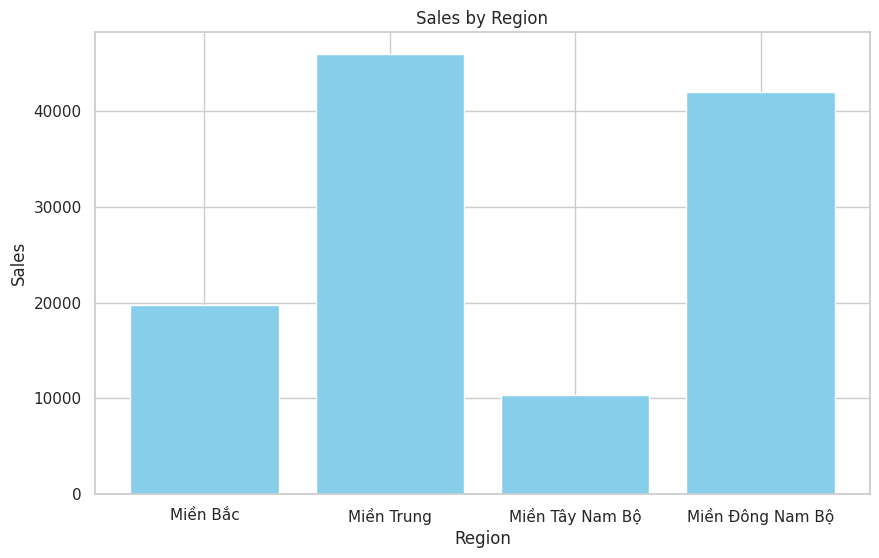

In [16]:
# Matplotlib
sale_region = df.groupby('Region')['Sales'].sum().reset_index()
plt.bar(sale_region['Region'], sale_region['Sales'], color='skyblue')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()


## 3.2 Line Chart (Biểu đồ đường)

In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Month'] = df['Order_Date'].dt.strftime('%b %y')

<ipython-input-19-9a770832127f>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])


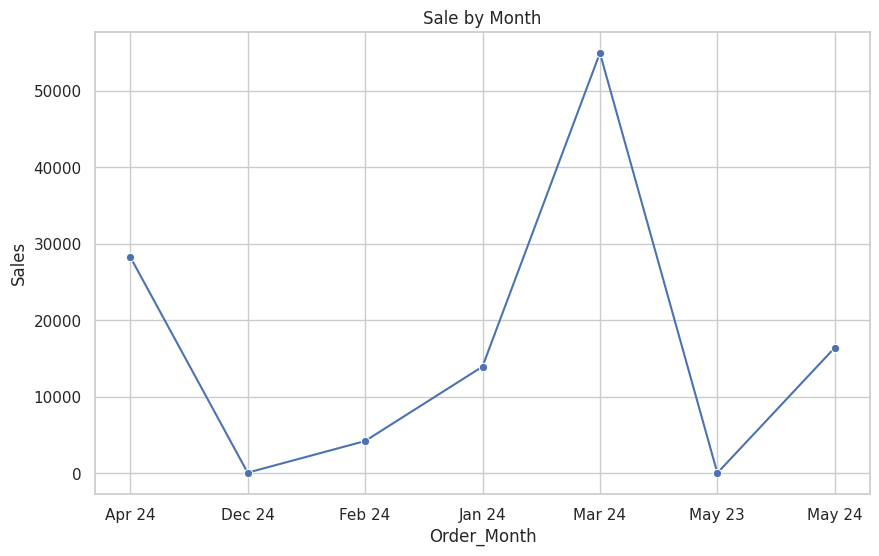

In [20]:
# Seaborn
sale_by_month = df.groupby('Order_Month')['Sales'].sum().reset_index()
sns.lineplot(data=sale_by_month, x='Order_Month', y='Sales', marker='o')
plt.title('Sale by Month')
plt.show()


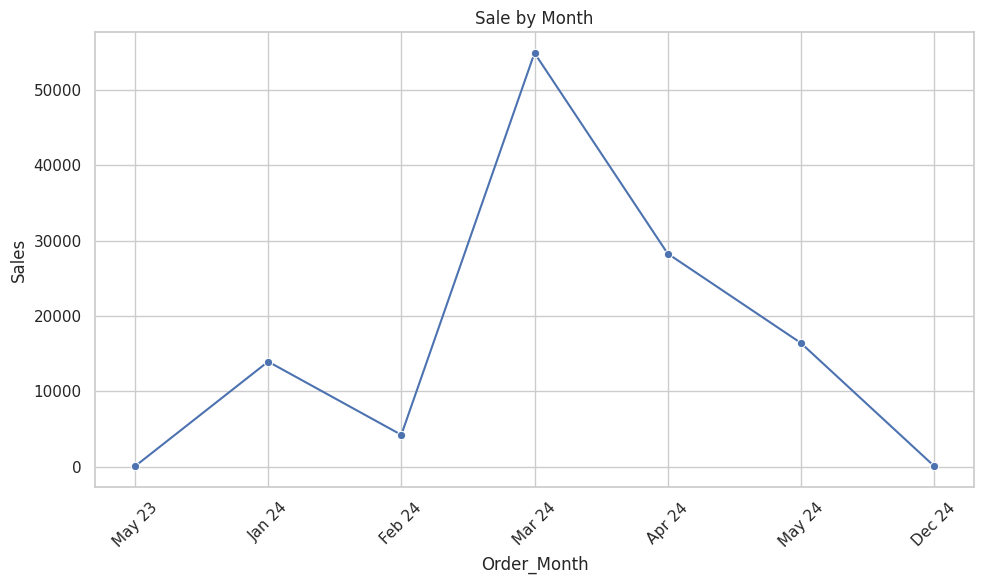

In [21]:
df['Order_Month'] = df['Order_Date'].dt.strftime('%b %y')
df['Order_Month_Sort'] = df['Order_Date'].dt.to_period('M').dt.to_timestamp()

# Bước 3: Group theo Order_Month và lấy tổng Sales
sale_by_month = (
    df.groupby(['Order_Month', 'Order_Month_Sort'])['Sales']
    .sum()
    .reset_index()
    .sort_values('Order_Month_Sort')  # Sắp xếp theo thời gian
)

# Bước 4: Vẽ biểu đồ
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=sale_by_month, x='Order_Month', y='Sales', marker='o')
plt.title('Sale by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.3 Pie Chart (Biểu đồ tròn)

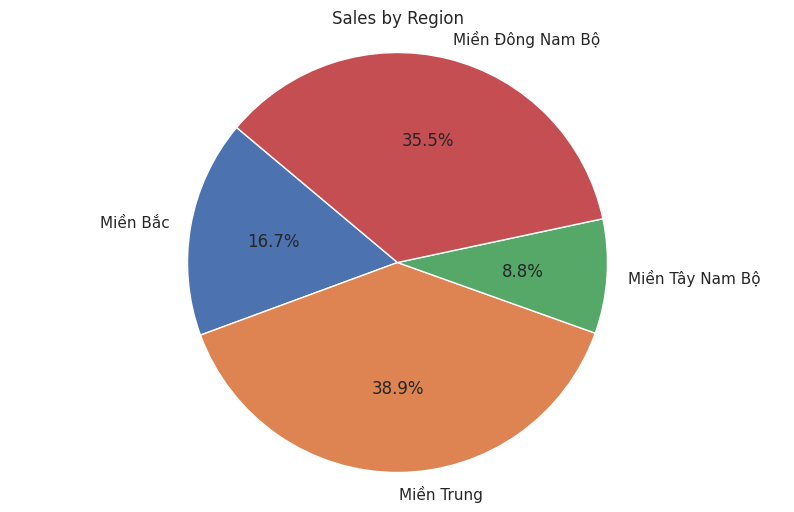

In [22]:
# Matplotlib
plt.pie(sale_region['Sales'], labels=sale_region['Region'], autopct='%1.1f%%', startangle=140)
plt.title('Sales by Region')
plt.axis('equal')
plt.show()


## 3.4 Heatmap (Biểu đồ ma trận nhiệt)

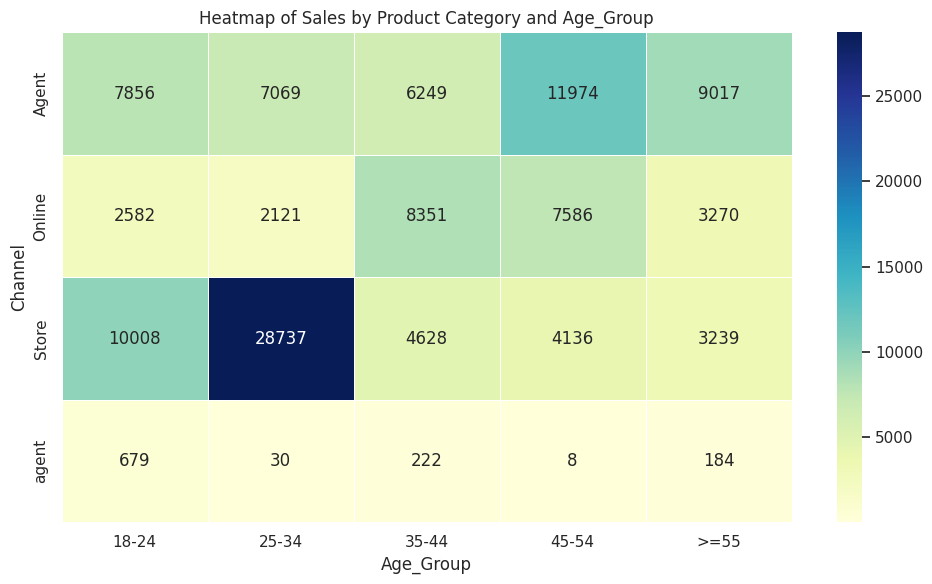

In [27]:
# Bước 1: Tổng hợp dữ liệu
pivot_table = df.pivot_table(
    values='Sales',
    index='Channel',
    columns='Age_Group',
    aggfunc='sum',
    fill_value=0
)

# Bước 2: Vẽ heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)

plt.title("Heatmap of Sales by Product Category and Age_Group")
plt.ylabel("Channel")
plt.xlabel("Age_Group")
plt.tight_layout()
plt.show()

## 3.5 Scatter Plot (Biểu đồ phân tán)

In [29]:
# Plotly tương tác
fig = px.scatter(df, x="Sales", y="Profit", color="Product_Category", size="Sales", title="Scatter Plot")
fig.show()


In [33]:
df1 = df[df['Order_ID'] != 'TT-2011-145317']

In [35]:
# Plotly tương tác
fig = px.scatter(df1, x="Sales", y="Profit", color="Product_Category", size="Sales", title="Scatter Plot")
fig.show()


## 3.6 boxplot

<ipython-input-32-4be0bad6ddfe>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




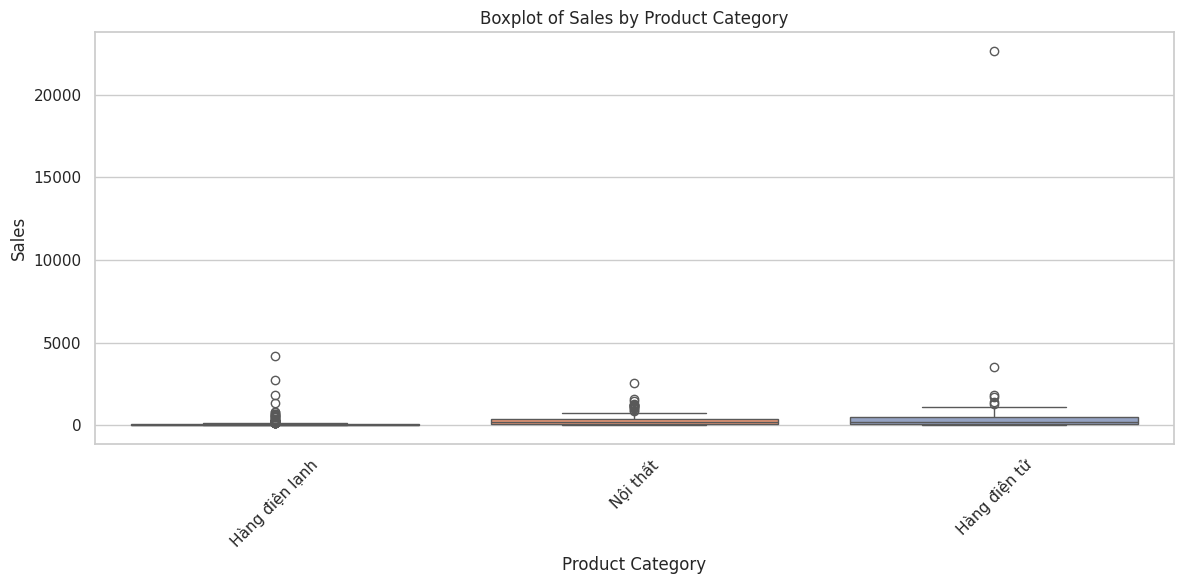

In [32]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Product_Category', y='Sales', palette='Set2')

plt.title('Boxplot of Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-34-a86b2f2c7b62>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




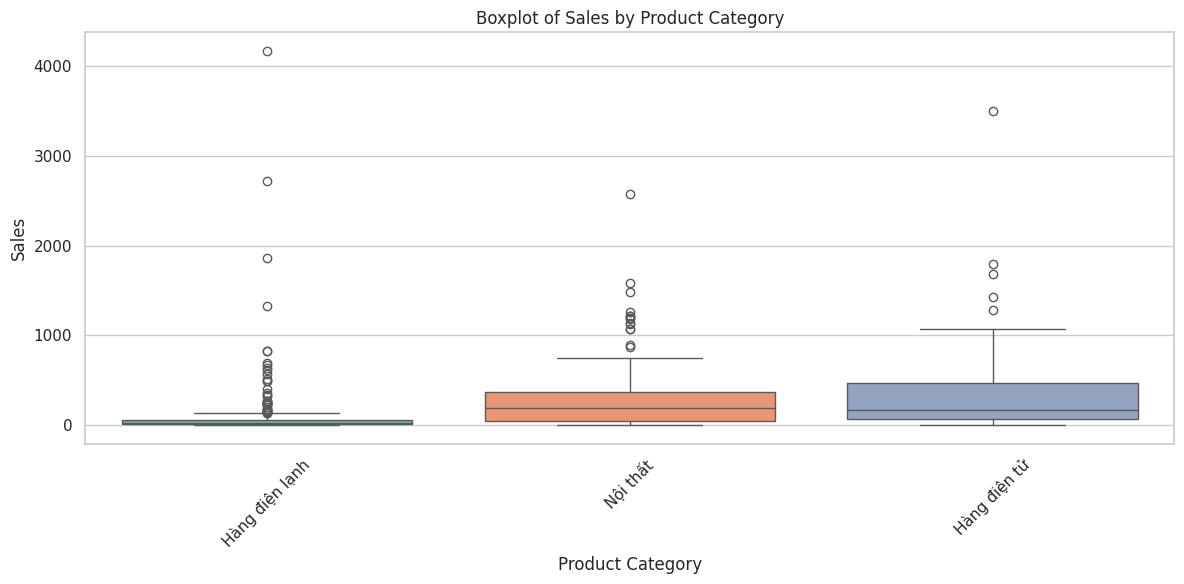

In [34]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=df1, x='Product_Category', y='Sales', palette='Set2')

plt.title('Boxplot of Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Bài tập

Hãy lựa chọn biểu đồ phù hợp, hãy trực quan các nội dung bên dưới
1. Sales by Channel
2. Sales by Customer_Segment
3. Sales by Province
4. Sales by Industry
5. Profit by Order_Date
6. Distribution of Profit by Customer_Segment
7. Correlation between Product_Sub-Category and Customer_Segment
8. Distribution of Sales by Product_Name
9. Profit by Product_Category and Product_Sub-Category
10. Correlation between Age_Group and Customer_Segment by Profit